In [5]:
import os
os.environ['STPSF_PATH'] = '/blue/adamginsburg/t.yoo/from_red/stpsf-data'
import stpsf as webbpsf

webbpsf.conf.STPSF_PATH = '/blue/adamginsburg/t.yoo/from_red/stpsf-data'

# Continue with other imports
from webbpsf.utils import to_griddedpsfmodel
import glob
from astropy.table import QTable, vstack
from jwst.datamodels import dqflags
import time
import numpy
import crowdsource
import regions
import numpy as np
from functools import cache
from astropy.convolution import convolve, Gaussian2DKernel, interpolate_replace_nans, convolve_fft
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.modeling.fitting import LevMarLSQFitter
from astropy import wcs
from astropy import table
from astropy import stats
from astropy import units as u
from astropy.nddata import NDData
from astropy.io import fits
from scipy import ndimage
import requests
import requests.exceptions
import urllib3
import urllib3.exceptions
from photutils.detection import DAOStarFinder
from crowdsource import crowdsource_base
from crowdsource.crowdsource_base import fit_im, psfmod
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from astropy.convolution import convolve, Gaussian2DKernel, interpolate_replace_nans, convolve_fft
from jwst.datamodels import dqflags
try:
    # version >=1.7.0, doesn't work: the PSF is broken (https://github.com/astropy/photutils/issues/1580?)
    from photutils.psf import PSFPhotometry, IterativePSFPhotometry, SourceGrouper
except:
    # version 1.6.0, which works
    from photutils.psf import BasicPSFPhotometry as PSFPhotometry, IterativelySubtractedPSFPhotometry as IterativePSFPhotometry, DAOGroup as SourceGrouper
try:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D, LocalBackground
except:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D
    from photutils.background import MMMBackground as LocalBackground
import matplotlib.pyplot as plt
from regions import PixCoord, CirclePixelRegion
class WrappedPSFModel(crowdsource.psf.SimplePSF):
    """
    wrapper for photutils GriddedPSFModel
    """
    def __init__(self, psfgridmodel, stampsz=19):
        self.psfgridmodel = psfgridmodel
        self.default_stampsz = stampsz

    def __call__(self, col, row, stampsz=None, deriv=False):

        if stampsz is None:
            stampsz = self.default_stampsz

        parshape = numpy.broadcast(col, row).shape
        tparshape = parshape if len(parshape) > 0 else (1,)

        # numpy uses row, column notation
        rows, cols = np.indices((stampsz, stampsz)) - (np.array([stampsz, stampsz])-1)[:, None, None] / 2.

        # explicitly broadcast
        col = np.atleast_1d(col)
        row = np.atleast_1d(row)
        #rows = rows[:, :, None] + row[None, None, :]
        #cols = cols[:, :, None] + col[None, None, :]

        # photutils seems to use column, row notation
        # only works with photutils <= 1.6.0 - but is wrong there
        #stamps = self.psfgridmodel.evaluate(cols, rows, 1, col, row)
        # it returns something in (nstamps, row, col) shape
        # pretty sure that ought to be (col, row, nstamps) for crowdsource

        # andrew saydjari's version here:
        # it returns something in (nstamps, row, col) shape
        stamps = []
        for i in range(len(col)):
            # the +0.5 is required to actually center the PSF (empirically)
            #stamps.append(self.psfgridmodel.evaluate(cols+col[i]+0.5, rows+row[i]+0.5, 1, col[i], row[i]))
            # the above may have been true when we were using (incorrectly) offset PSFs
            stamps.append(self.psfgridmodel.evaluate(cols+col[i], rows+row[i], 1, col[i], row[i]))

        stamps = np.array(stamps)

        # for oversampled stamps, they may not be normalized
        stamps /= stamps.sum(axis=(1,2))[:,None,None]
        # this is evidently an incorrect transpose
        #stamps = np.transpose(stamps, axes=(0,2,1))

        if deriv:
            dpsfdrow, dpsfdcol = np.gradient(stamps, axis=(1, 2))

        ret = stamps
        if parshape != tparshape:
            ret = ret.reshape(stampsz, stampsz)
            if deriv:
                dpsfdrow = dpsfdrow.reshape(stampsz, stampsz)
                dpsfdcol = dpsfdcol.reshape(stampsz, stampsz)
        if deriv:
            ret = (ret, dpsfdcol, dpsfdrow)

        return ret

    def render_model(self, col, row, stampsz=None):
        """
        this function likely does nothing?
        """
        if stampsz is not None:
            self.stampsz = stampsz

        rows, cols = np.indices(self.stampsz, dtype=float) - (np.array(self.stampsz)-1)[:, None, None] / 2.

        return self.psfgridmodel.evaluate(cols, rows, 1, col, row).T.squeeze()




def inject_synthetic_stars(img):
    # use psf_grid in stpsf package to inject synthetic stars
    pass


def get_psf_model(filtername, proposal_id, field,
                  module,
                  obsdate=None,
                  target='w51',
                  stampsz=19,
                  oversample=1,
                  basepath='/orange/adamginsburg/jwst/'):
    """
    Return two types of PSF model, the first for DAOPhot and the second for Crowdsource
    """
    if filtername.upper() in ['F140M', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N',
                              'F200W', 'F210M', 'F212N', 'F250M', 'F300M', 'F322W2',
                              'F335M', 'F356W', 'F360M', 'F410M', 'F430M', 'F444W',
                              'F460M', 'F466N', 'F480M']:
        instrument = 'NIRCam'
    else:
        instrument = 'MIRI'

    basepath = f'{basepath}/{target}'
    psf_dir = "."

    psf_fn = (
        f"{psf_dir}/"
        f"{instrument.lower()}_{module}_{filtername.lower()}_fovp101_samp4_npsf16.fits"
    )
    print('psf_fn', psf_fn, flush=True)
    if os.path.exists(psf_fn):
        print(f"Loading cached PSF grid: {psf_fn}", flush=True)
        grid = to_griddedpsfmodel(psf_fn)
        psf_model = WrappedPSFModel(grid, stampsz=stampsz)
        
    else:
        
        has_downloaded = False
        ntries = 0
        
        while not has_downloaded:
            ntries += 1
            try:
                print("Attempting to download WebbPSF data", flush=True)
                if filtername.upper() in ['F140M', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N',
                                  'F200W', 'F210M', 'F212N', 'F250M', 'F300M', 'F322W2',
                                  'F335M', 'F356W', 'F360M', 'F410M', 'F430M', 'F444W',
                                  'F460M', 'F466N', 'F480M']:
                    nrc = webbpsf.NIRCam()
                    #print('nrc=webbpsf.NIRCam()', flush=True)
                else:
                    nrc = webbpsf.MIRI()
                   # print('nrc=webbpsf.MIRI()', flush=True)
                nrc.load_wss_opd_by_date(f'{obsdate}T00:00:00')
                nrc.filter = filtername
                if module in ('nrca', 'nrcb'):
                    if 'F4' in filtername.upper() or 'F3' in filtername.upper():
                        nrc.detector = f'{module.upper()}5' # I think NRCA5 must be the "long" detector?
                    else:
                        nrc.detector = f'{module.upper()}1' #TODO: figure out a way to use all 4?
                    # default oversampling is 4
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=False, verbose=True, save=True)
                elif 'mirimage' in module:
                    print('module', module, flush=True)
                    print(nrc.detector)
                    nrc.detector = 'MIRIM'
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=False, verbose=True, save=True)
                else:
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=True, verbose=True, save=True)
                has_downloaded = True
            except (urllib3.exceptions.ReadTimeoutError, requests.exceptions.ReadTimeout, requests.HTTPError) as ex:
                print(f"Failed to build PSF: {ex}", flush=True)
            except Exception as ex:
                print(ex, flush=True)
                if ntries > 10:
                    # avoid infinite loops
                    raise ValueError("Failed to download PSF, probably because of an error listed above")
                else:
                    continue
        if isinstance(grid, list):
            grid = grid[0]

        #yy, xx = np.indices([31,31], dtype=float)
        #grid.x_0 = grid.y_0 = 15.5
        #psf_model = crowdsource.psf.SimplePSF(stamp=grid(xx,yy))

        # bigger PSF probably needed
        yy, xx = np.indices([61, 61], dtype=float)
        grid.x_0 = grid.y_0 = 30
        psf_model = crowdsource.psf.SimplePSF(stamp=grid(xx, yy))

            
        
    return grid, psf_model
        
def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    data = im1['SCI'].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    err = im1['ERR'].data
    instrument = im1[0].header['INSTRUME']
    telescope = im1[0].header['TELESCOP']
    obsdate = im1[0].header['DATE-OBS']
    return fh, im1, data, wht, err, instrument, telescope, obsdate    

def get_filenames(basepath, filtername, proposal_id, field, each_suffix, module, pupil='clear', visitid='001'):

    # jw01182004002_02101_00012_nrcalong_destreak_o004_crf.fits
    # jw02221001001_07101_00012_nrcalong_destreak_o001_crf.fits
    # jw02221001001_05101_00022_nrcb3_destreak_o001_crf.fits
        #jw06151002001_02101_00001_mirimage_i2d.fits

    glstr = f'{basepath}/{filtername}/pipeline/jw0{proposal_id}{field}*{module}*_{each_suffix}.fits'
    
  
    fglob = glob.glob(glstr)
    for st in fglob:
        print(st)
        if 'align' in st or 'uncal' in st:
            print(f"Removing {st} from glob string because it is an alignment file")
            fglob.remove(st)
    if len(fglob) == 0:
        raise ValueError(f"No matches found to {glstr}")
    else:
        return fglob


def inject_synthetic_stars(img, dqarr, psf_model, grid, flux, ww,  filtername,fwhm_pix, star_cat, grid_spacing=100, err=None, stampsz=19, nsigma=4):
    """
    Inject synthetic stars in a grid pattern across the image
    
    Parameters
    ----------
    img : ndarray
        The image data to inject stars into
    psf_model : WrappedPSFModel
        The PSF model to use for injection
    flux_range : array-like
        Array of flux values to test
    grid_spacing : int
        Spacing between injected stars in pixels
    err : ndarray, optional
        Error array for the image
    stampsz : int
        Size of PSF stamp
        
    Returns
    -------
    results : dict
        Dictionary containing injection and recovery information for each flux level
    """
    from photutils.detection import DAOStarFinder
    from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans, convolve_fft
    
    pixel_scale = ww.proj_plane_pixel_area()**0.5
    ny, nx = img.shape
    
    # Create grid of injection positions (avoiding edges)
    margin = stampsz
    x_positions = np.arange(margin, nx - margin, grid_spacing)
    y_positions = np.arange(margin, ny - margin, grid_spacing)
    xx, yy = np.meshgrid(x_positions, y_positions)
    
    # Flatten to get list of positions
    inject_x = xx.flatten()
    inject_y = yy.flatten()

    # create a 3d array of shape (len(x_positions), len(y_positions), len(flux_range)) to check which flux level the injected stars are detected at
    completeness_arr = np.full((len(y_positions), len(x_positions)), np.nan)

    print(f"Injecting {len(inject_x)} stars per flux level")
    edge_count =0
    
    completeness_values = []
    print(f"\nTesting flux level: {flux:.2e}")
    
    # Create image with injected stars
    img_with_stars = img.copy()

    
    # Inject stars at grid positions (vectorized)
    psf_stamps = np.asarray(psf_model(inject_x, inject_y, stampsz=stampsz))

    # Force shape to (nstar, stamp_h, stamp_w)
    if psf_stamps.ndim == 2:
        psf_stamps = psf_stamps[None, :, :]
    elif psf_stamps.ndim == 4 and psf_stamps.shape[1] == 1:
        psf_stamps = psf_stamps[:, 0, :, :]
    elif psf_stamps.ndim != 3:
        raise ValueError(f"Unexpected PSF stamp shape: {psf_stamps.shape}")
    dao_psf_model = grid


    # conduct PSF photometry on psf_stamps and get the normalization factor to convert from psf_stamps to flux units
    init_params = QTable()
    init_params['x'] = [psf_stamps[0].shape[1] / 2]
    init_params['y'] = [psf_stamps[0].shape[0] / 2]
    phot_test = PSFPhotometry(
        grouper=None,
                            # localbkg_estimator=None, # must be none or it un-saturates pixels
                            localbkg_estimator=LocalBackground(5, 15),
                            psf_model=dao_psf_model,
                            fitter=LevMarLSQFitter(),
                            fit_shape=(5, 5),
                            aperture_radius=2*fwhm_pix,
                            progress_bar=False,
    )
    test_run = phot_test(psf_stamps[0], init_params=init_params)


    flux_jy = flux.to_value(u.Jy)

    # pi xel solid angle in sr/pixel
    pix_area_sr = ww.proj_plane_pixel_area().to_value(u.sr)

    # required peak/amplitude in MJy/sr for a PSF normalized to sum=1 over pixels
    target_amp_mjysr = flux_jy / (pix_area_sr * 1e6)

    test_run = phot_test(psf_stamps[0], init_params=init_params)
    amp0 = float(test_run['flux_fit'][0])  # amplitude for current unscaled stamp

    norm_factor = target_amp_mjysr / amp0
    scaled_stamps = psf_stamps * norm_factor
    #norm_factor = flux.value / test_run['flux_fit'][0]   # pure float
    #scaled_stamps = psf_stamps * norm_factor 
    print('minmax of scaled stamps', np.nanmin(scaled_stamps), np.nanmax(scaled_stamps))

    test_run_scaled = phot_test(scaled_stamps[0], init_params=init_params)
    print(f"Test run on scaled stamp: fitted flux = {test_run_scaled['flux_fit'][0]:.2e} Jy, expected flux = {flux:.2e} Jy, norm_factor = {norm_factor:.2e}")
    # if the flux from text_run_scales is deviated from the expected flux by more than 20%, raise an error

    test_run_scaled = phot_test(scaled_stamps[0], init_params=init_params)
    amp_scaled = float(test_run_scaled['flux_fit'][0])  # MJy/sr
    flux_recovered_jy = amp_scaled * pix_area_sr * 1e6

    print(f"Recovered ~{flux_recovered_jy:.3e} Jy, target {flux_jy:.3e} Jy")
    #if np.abs(test_run_scaled['flux_fit'][0] - flux.value) / flux.value > 0.2:
    #    raise ValueError(f"Normalization factor seems incorrect: fitted flux = {test_run_scaled['flux_fit'][0]:.2e} Jy, expected flux = {flux:.2e} Jy, norm_factor = {norm_factor:.2e}")


    # Use actual stamp shape (not assumed stampsz) so indices and values match
    nstar, stamp_h, stamp_w = scaled_stamps.shape
    y_lo = stamp_h // 2
    y_hi = stamp_h - y_lo
    x_lo = stamp_w // 2
    x_hi = stamp_w - x_lo

    # add saturated or nan pixels into the mask
    is_nan = np.isnan(img)
    is_saturated = (dqarr & dqflags.pixel['SATURATED']) != 0

    # add 2fwhm area around star positions from star_catalog into the mask
    skycoord_stars = star_cat['skycoord']
    x_star, y_star = ww.world_to_pixel(skycoord_stars)

    # nearest pixel center
    xi = np.rint(x_star).astype(int)
    yi = np.rint(y_star).astype(int)

    # keep only stars inside image
    in_bounds = (
        (xi >= 0) & (xi < img.shape[1]) &
        (yi >= 0) & (yi < img.shape[0])
    )
    xi = xi[in_bounds]
    yi = yi[in_bounds]

    # seed mask: one write for all stars
    seed = np.zeros(img.shape, dtype=bool)
    seed[yi, xi] = True

    # circular structuring element with radius = 2*fwhm_pix
    r = int(np.ceil(2 * fwhm_pix))
    yy, xx = np.ogrid[-r:r+1, -r:r+1]
    disk = (xx*xx + yy*yy) <= (r*r)

    # final star mask
    is_stars = ndimage.binary_dilation(seed, structure=disk)


    
    # Index into 2D masks at injection positions
    is_nan_at_pos = is_nan[inject_y.astype(int), inject_x.astype(int)]
    is_saturated_at_pos = is_saturated[inject_y.astype(int), inject_x.astype(int)]

    valid_mask = (
        (inject_y >= y_lo) & (inject_y < ny - (y_hi - 1)) &
        (inject_x >= x_lo) & (inject_x < nx - (x_hi - 1)) &
        (~is_saturated_at_pos) & (~is_nan_at_pos) & (~is_stars[inject_y.astype(int), inject_x.astype(int)])
)

    edge_count = int(np.sum(~valid_mask))
    valid_x = inject_x[valid_mask].astype(int)
    valid_y = inject_y[valid_mask].astype(int)
    valid_stamps = scaled_stamps[valid_mask]

    if valid_stamps.size > 0:
        y_offsets = np.arange(-y_lo, y_hi, dtype=int)
        x_offsets = np.arange(-x_lo, x_hi, dtype=int)

        yy = valid_y[:, None, None] + y_offsets[None, :, None]   # (N, H, 1)
        xx = valid_x[:, None, None] + x_offsets[None, None, :]   # (N, 1, W)

        # Check against broadcasted index shape, not yy.size alone
        bshape = np.broadcast_shapes(yy.shape, xx.shape)         # (N, H, W)
        n_index = int(np.prod(bshape))
        n_value = int(valid_stamps.size)

        if n_index != n_value:
            raise ValueError(
                f"Index/value mismatch after broadcast: idx={n_index}, vals={n_value}, "
                f"yy_shape={yy.shape}, xx_shape={xx.shape}, stamp_shape={valid_stamps.shape}"
            )

        np.add.at(img_with_stars, (yy, xx), valid_stamps)

        filtered_errest = np.nanmedian(err) 
        daofind_tuned = DAOStarFinder(threshold=nsigma * filtered_errest,
                                fwhm=fwhm_pix, roundhi=1.0, roundlo=-1.0,
                                sharplo=0.30, sharphi=1.40)

       # integer center indices for injection grid
        ix = inject_x.astype(int)
        iy = inject_y.astype(int)

        # choose ONE saturation definition for both injection + detection
        sat_mask = (dqarr & dqflags.pixel['SATURATED']) != 0
        sat_mask = ndimage.binary_dilation(sat_mask, iterations=1)  # optional, but keep consistent

        # bad pixels anywhere on image
        bad_pixel = np.isnan(img_with_stars) | sat_mask | is_stars

        # center-allowed map (where a full stamp can fit)
        center_allowed = np.zeros((ny, nx), dtype=bool)
        center_allowed[y_lo:ny-(y_hi-1), x_lo:nx-(x_hi-1)] = True

        # 1) injection-position validity (point samples)
        valid_mask = center_allowed[iy, ix] & (~bad_pixel[iy, ix])

        # 2) finder mask (2D): True means "ignore in DAOStarFinder"
        mask = (~center_allowed) | bad_pixel
        
        
        found_stars = daofind_tuned(img_with_stars,
                          )


    print('the number of injected stars that were valid for injection:', np.sum(valid_mask))
    # Match injected to detected stars
    if found_stars is not None and len(found_stars) > 0:
        # Match within tolerance
        tolerance = 1.0 * pixel_scale  # pixels
        print(tolerance)

        pixcoord_found_stars = np.array(list(zip(found_stars['xcentroid'], found_stars['ycentroid'])))
        skycoord_found_stars = ww.pixel_to_world(found_stars['xcentroid'], found_stars['ycentroid'])
        pixcoord_injected_stars = np.array(list(zip(inject_x[valid_mask], inject_y[valid_mask])))
        skycoord_injected_stars = ww.pixel_to_world(inject_x[valid_mask], inject_y[valid_mask])
        matches, sep, _ = skycoord_found_stars.match_to_catalog_sky(skycoord_injected_stars, nthneighbor=1)

        print('tolerance:', tolerance)
        print('sep:', sep)
        matched = sep < tolerance
        matched_idx = np.where(matched)[0]
        if matched_idx.size == 0:
            print("No matched detections; skipping PSFPhotometry for this flux.")
            result = Table(names=['x_fit', 'y_fit', 'flux_fit'], dtype=[float, float, float])
        else:
            init_params = QTable()
            # Force 1D arrays (photutils expects a list/array of positions)
            init_params['x'] = np.atleast_1d(inject_x[valid_mask][matches[matched_idx]])
            init_params['y'] = np.atleast_1d(inject_y[valid_mask][matches[matched_idx]])

            phot_basic = PSFPhotometry(
                grouper=None,
                localbkg_estimator=LocalBackground(5, 15),
                psf_model=dao_psf_model,
                fitter=LevMarLSQFitter(),
                fit_shape=(5, 5),
                aperture_radius=2*fwhm_pix,
                progress_bar=False,
            )
            result = phot_basic(img_with_stars, init_params=init_params)
        print('the number of detections matched to injected stars:', np.sum(matched))
    """
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(1,2, 1)
    ax2 = fig.add_subplot(1,2, 2)
    ax1.imshow(img_with_stars, origin='lower', norm=simple_norm(img_with_stars, 'sqrt', percent=99.5))
    ax2.imshow(img_with_stars-img, origin='lower', norm=simple_norm(img_with_stars-img, 'sqrt', percent=99.5))  
    ax1.scatter(inject_x[valid_mask], inject_y[valid_mask], s=50, edgecolor='red', facecolor='none', label='Injected Stars')
    ax1.scatter(found_stars['xcentroid'][matched_idx], found_stars['ycentroid'][matched_idx], s=50, edgecolor='blue', facecolor='none', label='Detected Stars')
    """
    yy0, xx0 = np.indices((stampsz, stampsz), dtype=float)
    cx = cy = (stampsz - 1) / 2.0

    # evaluate at center; signature is evaluate(x, y, flux, x_0, y_0)
    psf_stamp0 = grid.evaluate(xx0, yy0, 1.0, grid.x_0, grid.y_0)
    psf_norm = np.nansum(psf_stamp0)

            
        
        # ...existing code...
        
    # convert check array to 2d array of shape (len(y_positions), len(x_positions)) where each element is the highest flux level at which the star was undetected
    tab = Table()
    avg_flux_app_array = np.full(len(result), np.nan)
    # make an array of the same shape as completeness_arr where each element is the average pixel values within aperture at the position of the injected stars
    for ii in range(len(result)):
        x = result['x_fit'][ii]
        y = result['y_fit'][ii]
        x = int(np.round(x))
        y = int(np.round(y))
        if x < 0 or x >= img.shape[1] or y < 0 or y >= img.shape[0]:
            continue
        aperture_radius = int(2*fwhm_pix)
        # make a circular aperture mask and get the flux within the aperture
        reg = CirclePixelRegion(PixCoord(x, y), aperture_radius)
        aperture_mask = reg.to_mask()
        aperture_data = aperture_mask.multiply(img)
        avg_flux_app = np.nansum(aperture_data) / np.sum(aperture_mask.data)
        avg_flux_app_array[ii] = avg_flux_app
    tab['x'] = result['x_fit']
    tab['y'] = result['y_fit']
    tab['avg_flux_app'] = avg_flux_app_array
    tab['flux_fit'] = result['flux_fit'] * pix_area_sr * 1e6  # MJy/sr to Jy using pixel scale and normalization factor
  

    return tab




def get_flux(
    filtername,
    A_V=0,
    temp=5000 * u.K,
    ext=CT06_MWLoc(),
    distance=5.4 * u.kpc,
    radius=10.0 * u.R_sun,
):
    from astropy.modeling.models import BlackBody
    from astroquery.svo_fps import SvoFps

    bb = BlackBody(temperature=temp)
    wave = np.linspace(1.3, 25.0, 1000) * u.micron

    # Specific intensity: e.g. erg / (s cm^2 Hz sr)
    I_nu = bb(wave)

    # Apparent solid angle of stellar disk: pi (R/d)^2 [sr]
    omega = np.pi * (radius / distance) ** 2 * u.sr

    # Flux density at observer (sr cancels)
    F_nu = I_nu * omega

    # Extinction
    F_nu_ext = F_nu * 10 ** (-0.4 * ext(wave) * A_V)

    if filtername.upper() in [
        "F140M", "F150W", "F162M", "F182M", "F187N", "F210M",
        "F335M", "F360M", "F410M", "F405N", "F480M"
    ]:
        instrument = "NIRCam"
    else:
        instrument = "MIRI"

    wavelength_table = SvoFps.get_transmission_data(
        f"JWST/{instrument.upper()}.{filtername.upper()}"
    )
    waves_svo = np.asarray(wavelength_table["Wavelength"])
    trans_svo = np.asarray(wavelength_table["Transmission"])

    trans_interpolated = np.interp(wave.to_value(u.micron), waves_svo, trans_svo)

    # Convert to Jy after sr cancellation
    F_nu_ext_jy = F_nu_ext.to(u.Jy, equivalencies=u.spectral_density(wave))

    flux_filter = (
        np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
        / np.trapz(trans_interpolated, wave.to_value(u.micron))
    ) * u.Jy
    return flux_filter

def main(
        proposal_id='6151',
         modules=['nrcalong'],
         filternames=['F480M'],
         target='w51', A_V_list=[0,  20,  40], temp_list = [3000*u.K, 5000*u.K, 10000*u.K], stampsz=19):
    
    
    nvisits = {'2221': {'brick': 1, 'cloudc': 2},
               '1182': {'brick': 2},
               '6151': {'w51': 1, 'w51_miri': 2}
               }
    field_to_reg_mapping = {'2221': {'001': 'brick', '002': 'cloudc'},
                            '1182': {'004': 'brick'},
                            '6151': {'001': 'w51', '002':'w51_miri'}}[proposal_id]
    reg_to_field_mapping = {v:k for k,v in field_to_reg_mapping.items()}
    field = reg_to_field_mapping[target]
    target_dir = target
    if proposal_id == '6151' and target == 'w51_miri':
        target_dir = 'w51'
    basepath = f'/orange/adamginsburg/jwst/{target_dir}/'



    # need to have incrementing _before_ test
    index = -1
    for filtername in filternames:
        if filtername.upper() in ['F140M', 'F162M', 'F182M', 'F187N', 'F210M']: 
            modules = ['nrca1', 'nrcb1', 'nrca2', 'nrcb2', 'nrca3', 'nrcb3', 'nrca4', 'nrcb4']
        else:
            modules = ['nrcalong', 'nrcblong']
        for module in modules:
            detector = module # no sub-detectors for long-NIRCAM
          
            for ii, visitid in enumerate(range(1, nvisits[proposal_id][target] + 1)):
                if True:
                    visitid = f'{visitid}'

                    filename = get_filenames(basepath, filtername, proposal_id,
                                                            field, visitid=visitid,
                                                            each_suffix='cal',
                                                            module=module, pupil='clear') [0] 
                    print('filename, ', filename)
                    vgroup = filename.split('/')[-1].split('_')[1]
                    exp = filename.split('/')[-1].split('_')[2]
                    #f140m_nrca4_visit001_vgroup03109_exp00008_daophot_daofind.fits
                    visitid_ = f'{int(visitid):03d}'                 
                    daofind_basic_catname = Table.read(f'{basepath}/{filtername.upper()}/{filtername.lower()}_{module}_visit{visitid_}_vgroup{vgroup}_exp{exp}_daophot_daofind.fits')
                    star_cat = Table(daofind_basic_catname)


                    fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(filename)
                    img = im1['SCI'].data
                    # set up coordinate system
                    ww = wcs.WCS(im1[1].header)
                    pixscale = ww.proj_plane_pixel_area()**0.5
                    cen = ww.pixel_to_world(im1[1].shape[1]/2, im1[1].shape[0]/2)
                    grid, psf_model = get_psf_model(filtername, proposal_id, field,
                                                    module=module,
                                                    # if we're doing each exposure, we want the full grid
                                                    target=target,
                                                    obsdate=obsdate,
                                                    basepath='/orange/adamginsburg/jwst/')
                    # add grid on the bkg_img
                

                    

                    fwhm_tbl = Table.read(f'{basepath}/reduction/fwhm_table.ecsv')
                    row = fwhm_tbl[fwhm_tbl['Filter'] == filtername]
                    fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
                    fwhm_pix = float(row['PSF FWHM (pixel)'][0])

                    

                    kernel = Gaussian2DKernel(x_stddev=fwhm_pix/2.355)
                    mask = np.isnan(img)
                    if 'DQ' in im1:
                        dqarr = im1['DQ'].data
                        is_saturated = (dqarr & dqflags.pixel['SATURATED']) != 0
                        # we want original image_with_synthetic_stars to be untouched for imshowing diagnostics etc.
                        img_ = img.copy()
                        img_[is_saturated] = np.nan
                        mask |= is_saturated
                    else:
                        img_ = img

                    nan_replaced_data = interpolate_replace_nans(img_, kernel, convolve=convolve_fft)

                   
                    for A_V in A_V_list:
                        for temp in temp_list:
                            flux = get_flux(filtername, A_V=A_V, temp=temp)
                            print(f"Injecting stars with flux {flux:.2e} Jy (A_V={A_V}, temp={temp})")
                            phot_result = inject_synthetic_stars(
                                nan_replaced_data, dqarr, psf_model, grid, flux, ww, filtername, fwhm_pix, star_cat,
                                grid_spacing=100, err=err, stampsz=stampsz
                            )                           
                            phot_result['A_V'] = A_V 
                            phot_result['temp'] = temp
                            phot_result['flux_injected'] = flux
                            if ii ==0:
                                all_phot_result = phot_result
                            else:
                                all_phot_result = vstack([all_phot_result, phot_result])
                            ii += 1
                    """
                    detected_sources = all_phot_result[~np.isnan(all_phot_result['avg_flux_app'])]
                    detected_coords = SkyCoord.from_pixel(detected_sources['x'], detected_sources['y'], ww)
                    detected_sources['ra'] = detected_coords.ra                   
                    detected_sources['dec'] = detected_coords.dec
                    detected_sources['filter'] = filtername
                    detected_sources['module'] = module
                    detected_sources['visitid'] = visitid
                    detected_sources['A_V'] = np.interp(detected_sources['flux_injected'], flux_range, A_V_list)
                    if ii==0 and jj==0:
                        final_table = detected_sources
                    else:
                        final_table = vstack([final_table, detected_sources])   
                
                    """
        fig = plt.figure(figsize=(10, 10))
        ax1 = fig.add_subplot(111)
        box_data = []
        box_labels = []
        box_colors = []
        cmap = plt.get_cmap('tab20')
        color_idx = 0
        for A_V in A_V_list:
            for temp in temp_list:
                subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp)]
                values = ((subset['flux_fit'] - subset['flux_injected']) / subset['flux_injected'])
                values = values[~np.isnan(values)]
                if len(values) > 0:
                    box_data.append(values)
                    box_labels.append(f'A_V={A_V}, temp={temp}')
                    box_colors.append(cmap(color_idx % 20))
                    color_idx += 1
        bp = ax1.boxplot(box_data, patch_artist=True, labels=box_labels)
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax1.tick_params(axis='x', rotation=45)
        ax1.set_xlabel('A_V and Temperature Labels')
        ax1.set_ylabel('(Average Flux in Aperture - Injected Flux) / Injected Flux')
        ax1.set_title(f'Flux Recovery Distribution by Label for {filtername} ')



/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00001_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00008_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00002_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00003_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00006_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00004_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00007_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00005_nrca1_cal.fits
filename,  /orange/adamginsburg/jwst/w51//F187N/pipeline/jw06151001001_03101_00001_nrca1_cal.fits
psf_fn ./nircam_nrca1_f187n_fovp101_samp4_npsf16.fits
Loading cached PSF grid: ./nircam_nrca1_f187n_fovp101_samp4_npsf16.fits


Set DATE-AVG to '2025-05-06T13:04:18.918' from MJD-AVG.
Set DATE-END to '2025-05-06T13:06:22.391' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/scratch/local/27964262/ipykernel_2408978/1034437857.py:612: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_2408978/1034437857.py:613: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))


Injecting stars with flux 5.36e-04 Jy Jy (A_V=0, temp=3000.0 K)
Injecting 441 stars per flux level

Testing flux level: 5.36e-04 Jy
minmax of scaled stamps 0.14141231406360313 3159.502755009086
Test run on scaled stamp: fitted flux = 2.34e+04 Jy, expected flux = 5.36e-04 Jy Jy, norm_factor = 2.03e+04
Recovered ~5.363e-04 Jy, target 5.363e-04 Jy
the number of injected stars that were valid for injection: 416
8.67444863794796e-06 deg
tolerance: 8.67444863794796e-06 deg
sep: [0d00m01.27514721s 0d00m01.60901303s 0d00m01.43804243s ...
 0d00m02.06575936s 0d00m01.56623952s 0d00m00.73092403s]
the number of detections matched to injected stars: 416
Injecting stars with flux 1.29e-03 Jy Jy (A_V=0, temp=5000.0 K)
Injecting 441 stars per flux level

Testing flux level: 1.29e-03 Jy


/scratch/local/27964262/ipykernel_2408978/1034437857.py:612: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_2408978/1034437857.py:613: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))


minmax of scaled stamps 0.3404295373562813 7606.042431919126
Test run on scaled stamp: fitted flux = 5.63e+04 Jy, expected flux = 1.29e-03 Jy Jy, norm_factor = 4.89e+04
Recovered ~1.291e-03 Jy, target 1.291e-03 Jy
the number of injected stars that were valid for injection: 416
8.67444863794796e-06 deg
tolerance: 8.67444863794796e-06 deg
sep: [0d00m01.27514721s 0d00m01.60901303s 0d00m01.43804243s ...
 0d00m02.06575936s 0d00m01.56623952s 0d00m00.73092403s]
the number of detections matched to injected stars: 416
Injecting stars with flux 3.46e-03 Jy Jy (A_V=0, temp=10000.0 K)
Injecting 441 stars per flux level

Testing flux level: 3.46e-03 Jy


...

/scratch/local/27964262/ipykernel_2408978/1034437857.py:612: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_2408978/1034437857.py:613: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))


minmax of scaled stamps 0.030748848095320157 592.8211248734899
Test run on scaled stamp: fitted flux = 4.37e+03 Jy, expected flux = 1.01e-04 Jy Jy, norm_factor = 3.76e+03
Recovered ~1.008e-04 Jy, target 1.008e-04 Jy
the number of injected stars that were valid for injection: 383
8.702654102030222e-06 deg
tolerance: 8.702654102030222e-06 deg
sep: [0d00m00.69488527s 0d00m03.88791808s 0d00m03.93779902s ...
 0d00m03.07050947s 0d00m01.10792608s 0d00m01.44602259s]
the number of detections matched to injected stars: 383
Injecting stars with flux 2.37e-04 Jy Jy (A_V=40, temp=10000.0 K)
Injecting 441 stars per flux level

Testing flux level: 2.37e-04 Jy


/scratch/local/27964262/ipykernel_2408978/1034437857.py:612: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_2408978/1034437857.py:613: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))


minmax of scaled stamps 0.07234753381223162 1394.8212382927459
Test run on scaled stamp: fitted flux = 1.03e+04 Jy, expected flux = 2.37e-04 Jy Jy, norm_factor = 8.86e+03
Recovered ~2.371e-04 Jy, target 2.371e-04 Jy
the number of injected stars that were valid for injection: 383
8.702654102030222e-06 deg
tolerance: 8.702654102030222e-06 deg
sep: [0d00m00.69488527s 0d00m03.88791808s 0d00m03.93779902s ...
 0d00m03.07050947s 0d00m01.10792608s 0d00m01.44602259s]
the number of detections matched to injected stars: 383


/scratch/local/27964262/ipykernel_2408978/1034437857.py:754: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, patch_artist=True, labels=box_labels)


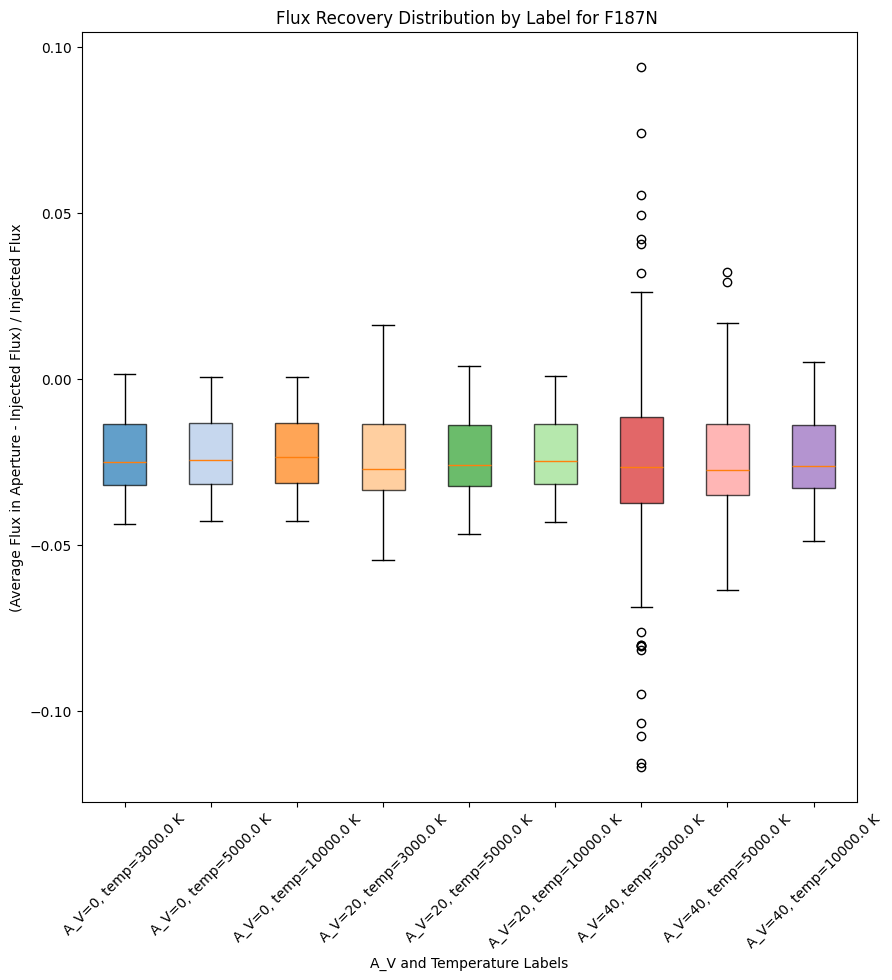

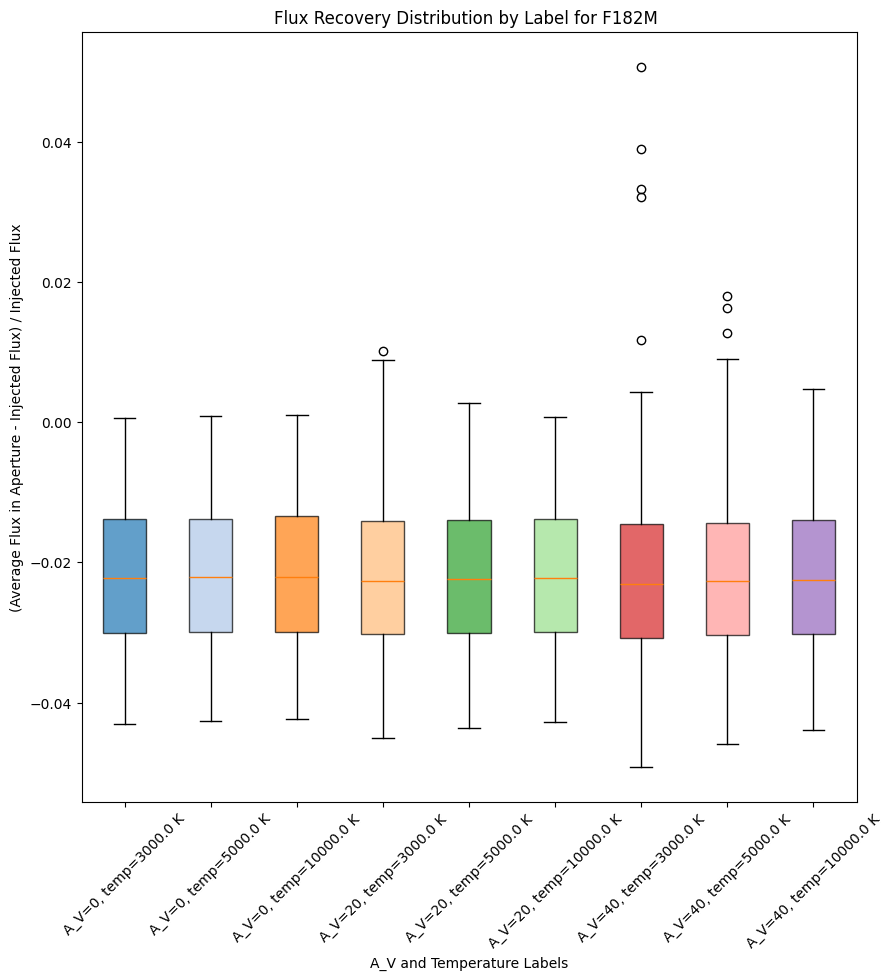

In [6]:
filternames = ['F187N', 'F182M']
main(filternames=filternames)